# Tarefa 1: Análise e Pré-processamento dos Dados

Este notebook realiza a exploração inicial do **Seeds Dataset** (UCI), com estatísticas descritivas, visualizações e pré-processamento para modelagem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

BASE_DIR = Path('..')  # src/notebooks -> src
DATA_DIR = BASE_DIR / 'data' / 'processed'

df = pd.read_csv(DATA_DIR / 'seeds_full.csv')
df.head()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,groove_length,variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Kama


## 1. Estatísticas descritivas

In [2]:
features = [c for c in df.columns if c != 'variety']

print('Dimensões:', df.shape)
print('\nDistribuição das variedades:')
print(df['variety'].value_counts())

print('\nEstatísticas descritivas:')
df[features].describe().T

Dimensões: (210, 8)

Distribuição das variedades:
variety
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64

Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
area,210.0,14.847524,2.909699,10.5900,12.27000,14.35500,17.305000,21.1800
perimeter,210.0,14.559286,1.305959,12.4100,13.45000,14.32000,15.715000,17.2500
compactness,210.0,0.870999,0.023629,0.8081,0.85690,0.87345,0.887775,0.9183
kernel_length,210.0,5.628533,0.443063,4.8990,5.26225,5.52350,5.979750,6.6750
kernel_width,210.0,3.258605,0.377714,2.6300,2.94400,3.23700,3.561750,4.0330
asymmetry_coefficient,210.0,3.700201,1.503557,0.7651,2.56150,3.59900,4.768750,8.4560
groove_length,210.0,5.408071,0.491480,4.5190,5.04500,5.22300,5.877000,6.5500


## 2. Medianas por característica e variedade

In [3]:
median_by_class = df.groupby('variety')[features].median().round(3)
median_by_class

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,groove_length
variety,,,,,,,
Canadian,11.835,13.25,0.849,5.224,2.835,4.839,5.092
Kama,14.355,14.32,0.881,5.534,3.244,2.546,5.094
Rosa,18.720,16.21,0.883,6.148,3.694,3.610,5.982


## 3. Histogramas das características

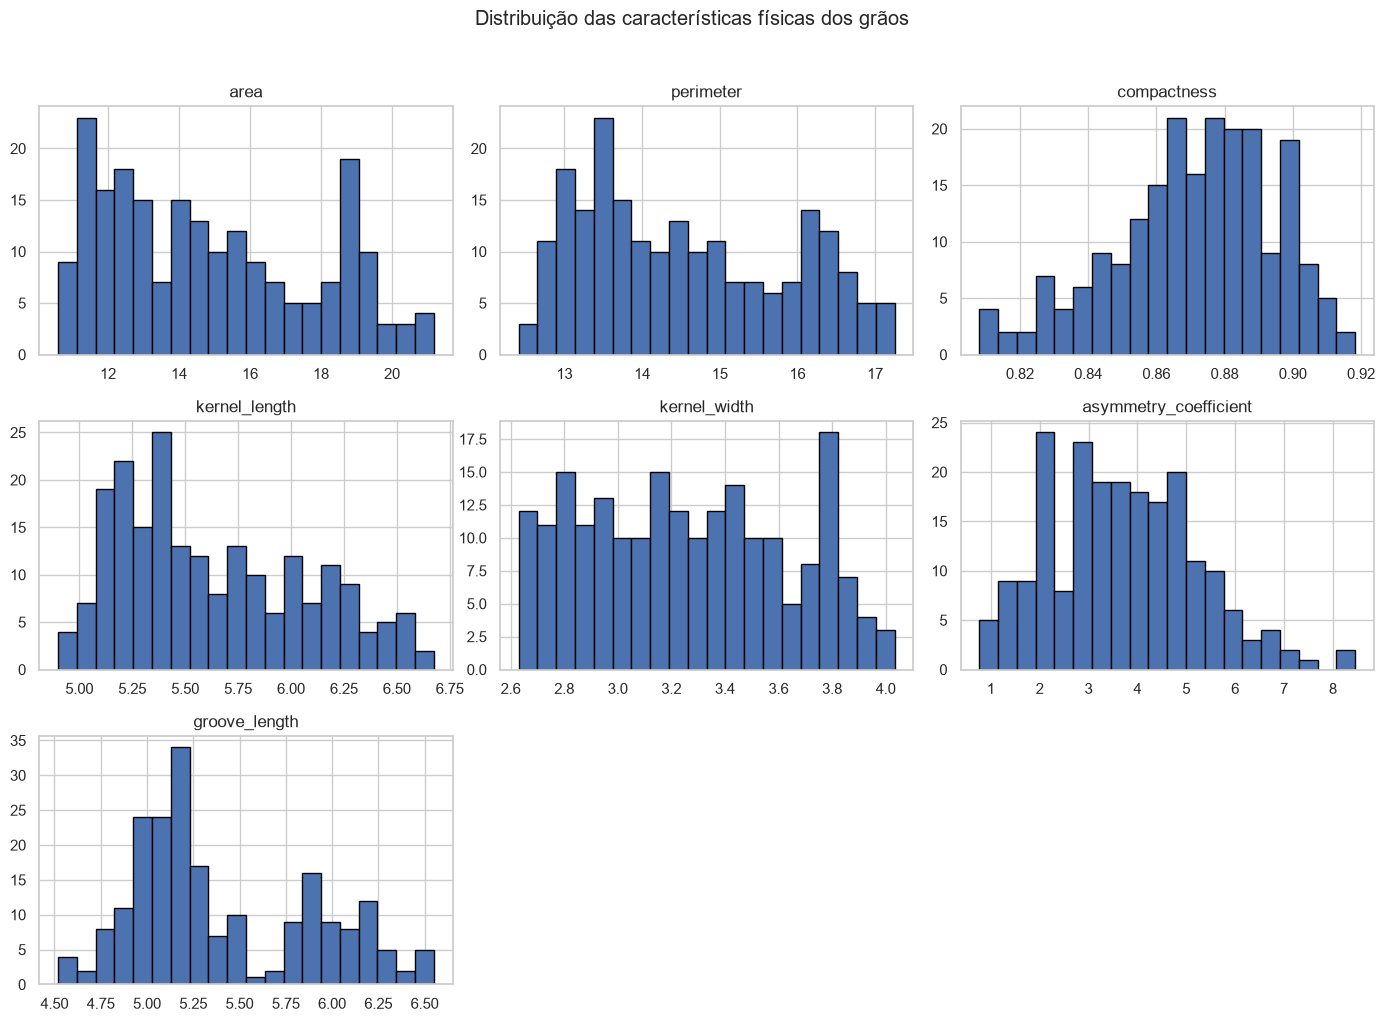

In [4]:
df[features].hist(bins=20, figsize=(14, 10), edgecolor='black')
plt.suptitle('Distribuição das características físicas dos grãos', y=1.02)
plt.tight_layout()
plt.show()

## 4. Boxplots por variedade

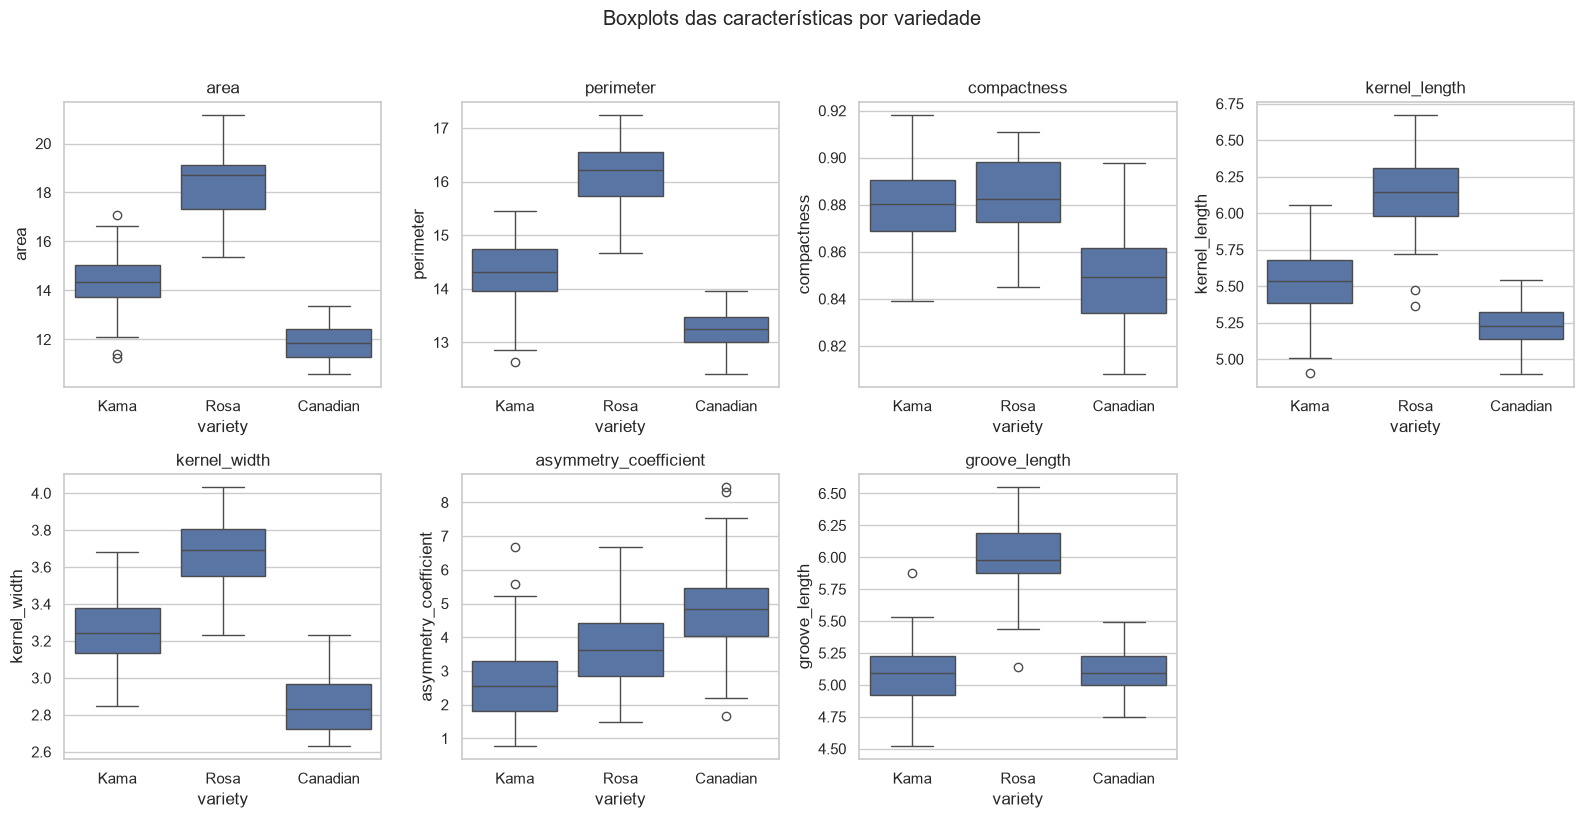

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for idx, col in enumerate(features):
    sns.boxplot(data=df, x='variety', y=col, ax=axes[idx])
    axes[idx].set_title(col)
axes[-1].axis('off')
plt.suptitle('Boxplots das características por variedade', y=1.02)
plt.tight_layout()
plt.show()

## 5. Gráficos de dispersão (pairplot)

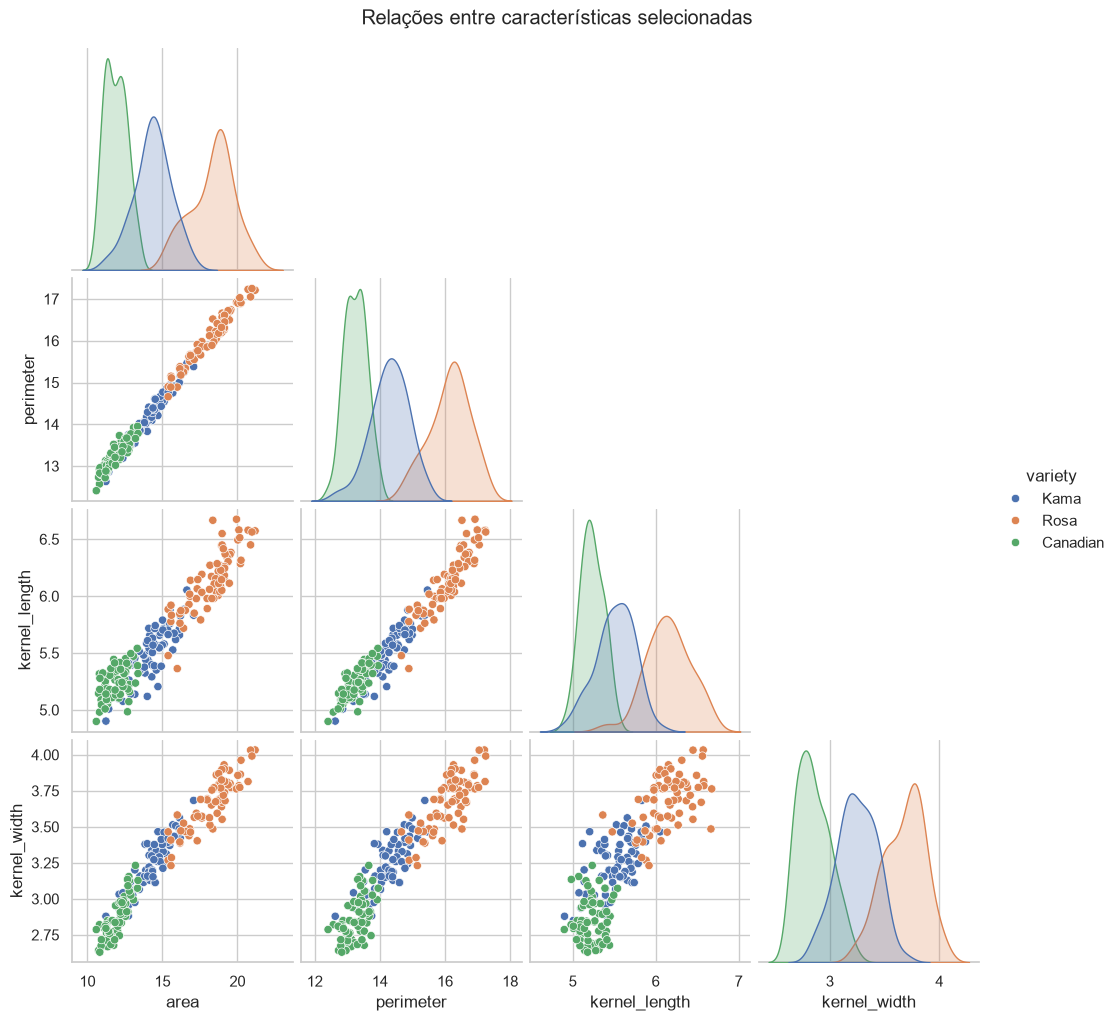

In [6]:
selected_features = ['area', 'perimeter', 'kernel_length', 'kernel_width']
sns.pairplot(df, vars=selected_features, hue='variety', corner=True, diag_kind='kde')
plt.suptitle('Relações entre características selecionadas', y=1.02)
plt.show()

## 6. Matriz de correlação

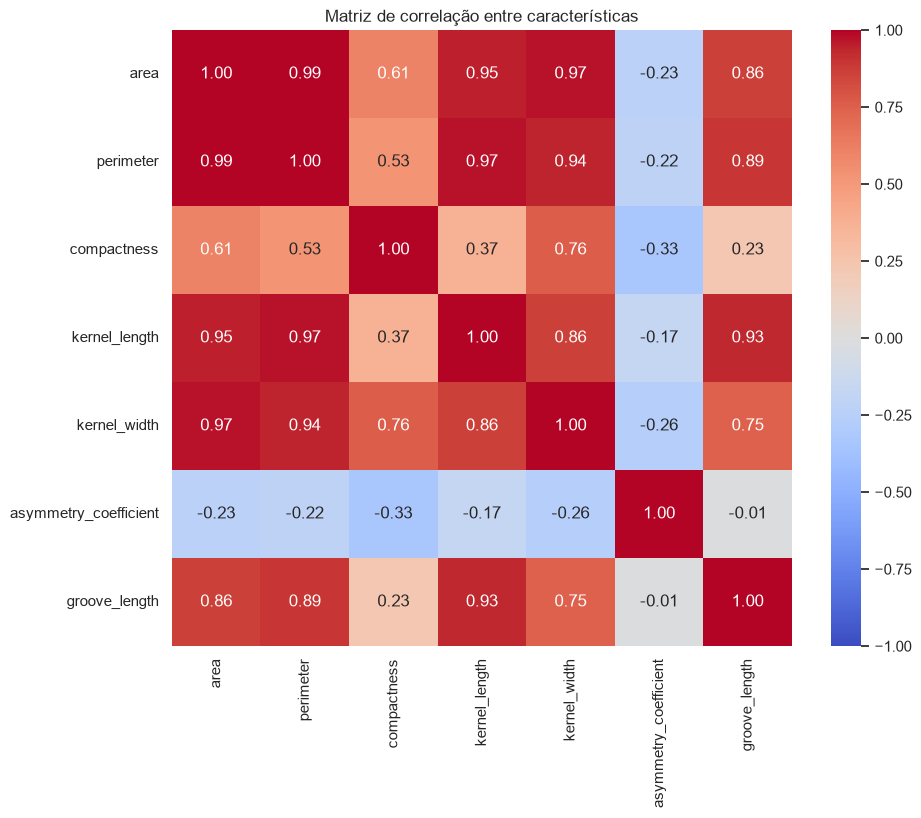

In [7]:
corr = df[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de correlação entre características')
plt.show()

## 7. Tratamento de valores ausentes e escala

- O dataset original não possui valores ausentes.
- A padronização já foi aplicada via `StandardScaler` no script `src/data/preprocess.py`, gerando os arquivos `seeds_train.csv` e `seeds_test.csv`.

In [8]:
print('Valores ausentes por coluna:')
print(df.isnull().sum())

train = pd.read_csv(DATA_DIR / 'seeds_train.csv')
test = pd.read_csv(DATA_DIR / 'seeds_test.csv')
print(f'\nTreino: {train.shape} | Teste: {test.shape}')
print('Média das features no treino (após padronização):')
print(train[features].mean().round(3).to_string())
print('Desvio padrão das features no treino:')
print(train[features].std().round(3).to_string())

Valores ausentes por coluna:
area                     0
perimeter                0
compactness              0
kernel_length            0
kernel_width             0
asymmetry_coefficient    0
groove_length            0
variety                  0
dtype: int64

Treino: (147, 8) | Teste: (63, 8)
Média das features no treino (após padronização):
area                     0.0
perimeter               -0.0
compactness              0.0
kernel_length           -0.0
kernel_width            -0.0
asymmetry_coefficient   -0.0
groove_length           -0.0
Desvio padrão das features no treino:
area                     1.003
perimeter                1.003
compactness              1.003
kernel_length            1.003
kernel_width             1.003
asymmetry_coefficient    1.003
groove_length            1.003
